<a href="https://colab.research.google.com/github/PauloFernandes26/AD2526/blob/main/AD2526_P4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup, Version check and Common imports

# Python ≥ 3.7 is required
import sys
assert sys.version_info >= (3, 7)


# TensorFlow ≥ 2.8 is required
import tensorflow as tf
from packaging import version

assert version.parse(tf.__version__) >= version.parse("2.8.0")

# Common imports
import numpy as np
import os
import pandas as pd

from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print('Python version: ', sys.version_info)
print('TF version: ', tf.__version__)
print('Keras version: ', keras.__version__)
print('GPU is', 'available' if tf.config.list_physical_devices('GPU') else 'NOT AVAILABLE')

Python version:  sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
TF version:  2.19.0
Keras version:  3.10.0
GPU is available


**A. CIFAR 100 Dataset: Fine grained Version**

**0. Obtaining and Splitting the Dataset into 3 Sets (Train, Test, Validation)**


In [2]:

# Load CIFAR100 dataset from keras datasets:
# https://keras.io/api/datasets/cifar100/
# https://www.cs.toronto.edu/~kriz/cifar.html

# The load_data() method creates train and test sets. The parameter label_mode specifies the category labels: 'fine' or 'coarse'
# In this class we will adopt the fine grained classification, corresponding to 100 categories

from keras.datasets import cifar100
from sklearn.model_selection import train_test_split

(train_images_full, train_labels_full), (test_images, test_labels) = cifar100.load_data(label_mode = 'fine')

train_labels_full = train_labels_full.squeeze()
test_labels = test_labels.squeeze()


# We further divide the original train datasets into train and validation datasets
train_images, valid_images, train_labels, valid_labels = train_test_split(
    train_images_full, train_labels_full,
    test_size=0.1,
    random_state=42,
    stratify=train_labels_full
)

# Normalize data to interval [0, 1]

train_images = train_images / 255.0
valid_images = valid_images / 255.0
test_images = test_images / 255.0


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


**1. Baseline CNN**

In [3]:
# Last class we struggled to achieve 30% in test accuracy when using a MLP
# Let's check how a plain CNN performs. No regularization or overfitting control techniques will be used.

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

CNN_Base = keras.Sequential([
    # Input layer (No Flatten layer)
    layers.Input(shape=[32,32,3]),

    # Feature extraction part
    layers.Conv2D(32, 3, activation='elu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation='elu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='elu', padding='same'),
    layers.MaxPooling2D(),

    #Classification part
    layers.Flatten(),
    layers.Dense(64, activation='elu'),

    # Final layer
    layers.Dense(100, activation='softmax')
])


CNN_Base.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.SGD(),
              metrics=['accuracy'])

CNN_Base.summary()

history = CNN_Base.fit(train_images, train_labels, batch_size=32, epochs=30,
                    validation_data=(valid_images, valid_labels))




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,740 (393.52 KB)

 Trainable params: 100,740 (393.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.0208 - loss: 4.5679 - val_accuracy: 0.0498 - val_loss: 4.3011
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.0660 - loss: 4.1776 - val_accuracy: 0.1078 - val_loss: 3.9096
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1279 - loss: 3.7968 - val_accuracy: 0.1536 - val_loss: 3.6611
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1734 - loss: 3.5497 - val_accuracy: 0.1742 - val_loss: 3.5066
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2071 - loss: 3.3510 - val_accuracy: 0.1972 - val_loss: 3.3570
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2362 - loss: 3.1885 - val_accuracy: 0.2224 - val_loss: 3.2235
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2602 - loss: 3.0465 - val_accuracy: 0.2404 - val_loss: 3.1211
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2835 - loss: 2.9200 

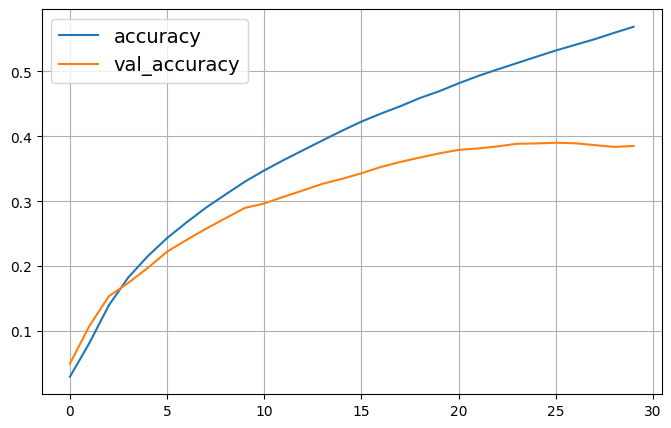

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3884 - loss: 2.6050
Test Accuracy: 0.3912000060081482


In [4]:
x = pd.DataFrame(history.history, columns = ['accuracy', 'val_accuracy'])
x.plot(figsize=(8, 5))
plt.grid(True)
plt.show()

test_loss, test_acc = CNN_Base.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_acc}")

**B. Flowers Dataset**

**1. Data Fetching and Loading**

In [5]:
# Download the Flowers dataset: https://www.kaggle.com/datasets/imsparsh/flowers-dataset

# Create folder flower_photos
# Inside this folder there are 5 subfolders, one for each category

!curl -O https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz

!tar -xzvf flower_photos.tgz

!rm flower_photos.tgz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  218M  100  218M    0     0  17.7M      0  0:00:12  0:00:12 --:--:-- 21.3M
flower_photos/
flower_photos/roses/
flower_photos/roses/14810868100_87eb739f26_m.jpg
flower_photos/roses/1446090416_f0cad5fde4.jpg
flower_photos/roses/15319767030_e6c5602a77_m.jpg
flower_photos/roses/15032112248_30c5284e54_n.jpg
flower_photos/roses/7211616670_2d49ecb3a5_m.jpg
flower_photos/roses/15674450867_0ced942941_n.jpg
flower_photos/roses/17158274118_00ec99a23c.jpg
flower_photos/roses/14019883858_e5d2a0ec10_n.jpg
flower_photos/roses/8035908422_87220425d2_n.jpg
flower_photos/roses/14747962886_2bff6bb323_m.jpg
flower_photos/roses/4356781875_92c5cd93c0.jpg
flower_photos/roses/8524505546_b242bd4928_n.jpg
flower_photos/roses/9406573080_60eab9278e_n.jpg
flower_photos/roses/6039330368_c30ed224c4_m.jpg
flower_photos/roses/14414100710_753a36fce9.jpg
flower_

In [6]:
# Check the total number of images

import pathlib

os.chdir('flower_photos')
path = os.getcwd()
data_dir = pathlib.Path(path)

image_count = len(list(data_dir.glob('*/*.jpg')))
print('Total images: ', image_count)

Total images:  3670


In [7]:
# The images in the original folders are not divided in train and validation datasets
# The following code divides samples into 80% training and 20% validation. No test set is created

# https://www.tensorflow.org/api_docs/python/tf/data/Dataset
# https://www.tensorflow.org/guide/data

# The method image_dataset_from_directory() creates Dataset objects from images located in a specified directory
# https://keras.io/api/data_loading/image/

# Parameters subset and validation_split enable the creation of two datasets (Train: 80%; Validation: 20%)
# This method may shuffle images, adjust size and define the batch size
# This way the dataset is (almost) ready to be processed by the neural network


batch_size = 32
IMG_SIZE = (180, 180)

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=batch_size,
)

class_names = train_ds.class_names


train_ds = train_ds.cache().prefetch(1)
val_ds = val_ds.cache().prefetch(1)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Using 734 files for validation.


In [8]:
# Dataset detailed information

print('Nr. of classes: ', len(class_names))
print('Classes: ', class_names, '\n')

# Cardinality
print('Cardinalidade Treino: ', train_ds.cardinality().numpy())
print('Cardinalidade Validacão: ', val_ds.cardinality().numpy(), '\n')

for image_batch, labels_batch in train_ds:
    print('Tensor Batch Image: ', image_batch.shape)
    print('Tensor Batch Label: ', labels_batch.shape)
    break

Nr. of classes:  5
Classes:  ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'] 

Cardinalidade Treino:  92
Cardinalidade Validacão:  23 

Tensor Batch Image:  (32, 180, 180, 3)
Tensor Batch Label:  (32,)


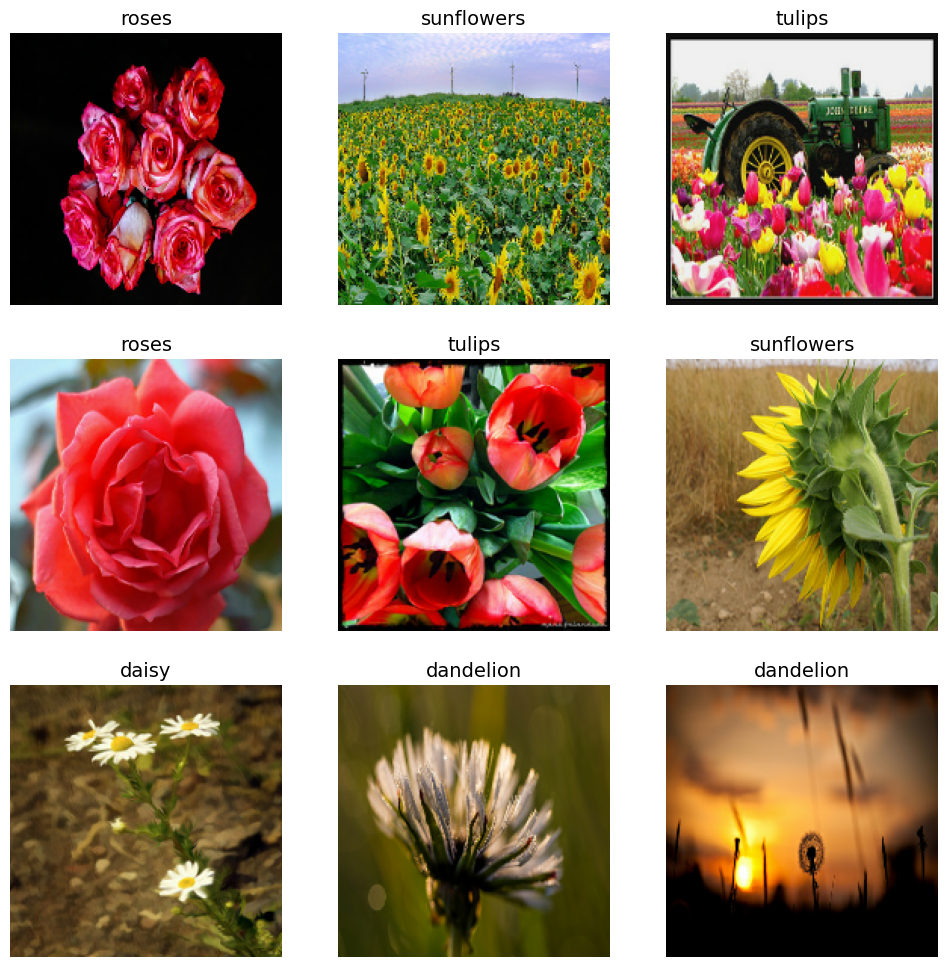

In [9]:
# Visualize a few examples

plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy()/255.)
        plt.title(class_names[labels[i]])
        plt.axis("off")

**2. Creating and Training a Baseline CNN: CNN_Flower1**

In [10]:
# Adapt the baseline CNN that we used in the CIFAR100 dataset to this new example
# For now, change just the input and output layers
# Note that the rescaling is performed by the neural network

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

CNN_Flower1 = keras.Sequential([

    ### Add Input layer ####
    layers.Input(shape=[180,180,3]),
    layers.Rescaling(scale = 1./255),


    # Feature extraction part

    layers.Conv2D(32, 3, activation='elu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation='elu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='elu', padding='same'),
    layers.MaxPooling2D(),


    #Classification part
    layers.Flatten(),
    layers.Dense(64, activation='elu'),

    ### Add Final layer ###
    layers.Dense(5, activation='softmax')

])


CNN_Flower1.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.SGD(),
              metrics=['accuracy'])

CNN_Flower1.summary()

history = CNN_Flower1.fit(
  train_ds,
  validation_data=val_ds,
  epochs=30
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,982,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,011,493 (7.67 MB)

 Trainable params: 2,011,493 (7.67 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.3599 - loss: 1.4657 - val_accuracy: 0.5163 - val_loss: 1.1804
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5219 - loss: 1.1721 - val_accuracy: 0.5599 - val_loss: 1.1029
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5608 - loss: 1.0889 - val_accuracy: 0.5668 - val_loss: 1.0710
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5940 - loss: 1.0227 - val_accuracy: 0.5736 - val_loss: 1.0510
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6143 - loss: 0.9681 - val_accuracy: 0.5817 - val_loss: 1.0390
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6418 - loss: 0.9179 - val_accuracy: 0.5858 - val_loss: 1.0346
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6661 - loss: 0.8684 - val_accuracy: 0.6008 - val_loss: 1.0367
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6902 - loss: 0.8189 - val_accuracy: 0.6035 -

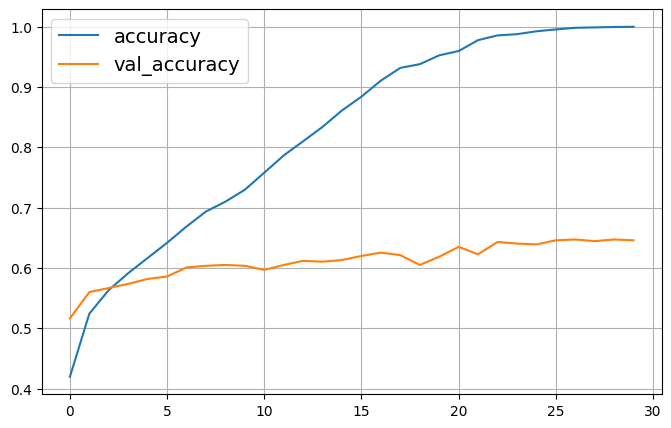

In [11]:

x = pd.DataFrame(history.history, columns = ['accuracy', 'val_accuracy'])
x.plot(figsize=(8, 5))
plt.grid(True)
plt.show()

**Question:**

How do you analyze results?

**3. Creating and Training an Improved CNN: CNN_Flower2**

In [15]:
# Design and implement changes in the CNN and repeat the training process,
# seeking for an architecture that performs more effectively.

# Among other possibilities, you might consider one of the following points:
#  1. Change the CNN architecture, adding, deleting, or changing the parameterization of convolutional, maxpooling or dense layers.
#  2. Change the Optimizer
#  3. Add Regularization, Batch Normalization or Dropout layers.
#  4. Add a callback to implement Early Stopping.

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

# Callback for Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Create a new model called CNN_Flower2

CNN_Flower2 = keras.Sequential([
    ###  CODE GOES HERE   ####

    #input + rescaling
    layers.Input(shape=[180,180,3]),
    layers.Rescaling(scale = 1./255),

    # Feature extraction part
    layers.Conv2D(32, 3, activation='elu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, activation='elu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, activation='elu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),


    #classification
    layers.Flatten(),
    layers.Dense(128, activation='elu'),
    layers.Dropout(0.40),
    layers.Dense(5, activation='softmax')

])

CNN_Flower2.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])

CNN_Flower2.summary()

history = CNN_Flower2.fit(
  train_ds,
  validation_data=val_ds,
  callbacks=[early_stopping],
  epochs=30

)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,024,773 (30.61 MB)

 Trainable params: 8,024,325 (30.61 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.3241 - loss: 13.5013 - val_accuracy: 0.2602 - val_loss: 7.5127
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.2992 - loss: 1.8818 - val_accuracy: 0.2657 - val_loss: 7.7069
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.3292 - loss: 1.7579 - val_accuracy: 0.3161 - val_loss: 2.0313
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.3186 - loss: 1.7229 - val_accuracy: 0.3719 - val_loss: 3.5305
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.3381 - loss: 1.6697 - val_accuracy: 0.4210 - val_loss: 4.2550
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.3564 - loss: 1.6100 - val_accuracy: 0.4428 - val_loss: 1.7059
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.3484 - loss: 1.5872 - val_accuracy: 0.4646 - val_loss: 2.4643
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.3612 - loss: 1.5464 - val_accuracy: 0.4401 

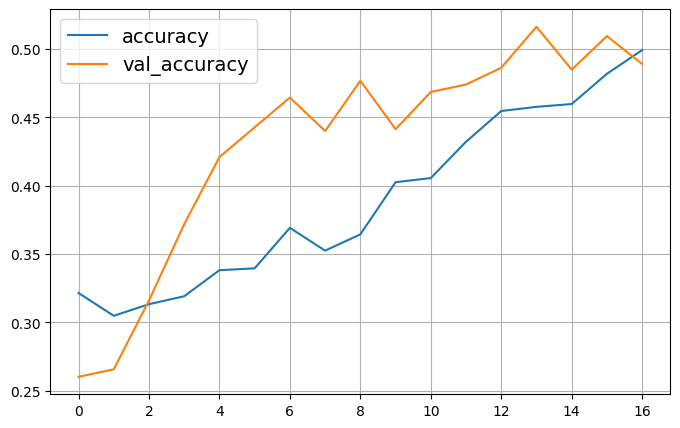

In [16]:
x = pd.DataFrame(history.history, columns = ['accuracy', 'val_accuracy'])
x.plot(figsize=(8, 5))
plt.grid(True)
plt.show()